#  Compensation in DC Government: A Data-Driven Analysis A Data-Driven Look at DC's Public Workforce



**MATH 014 – Introduction to Data Science | Spring 2026 | Howard University**



## 01 | Title and Introduction

The District of Columbia employs tens of thousands of people across dozens of agencies; from firefighters and teachers to policy analysts and engineers. But how are those salaries actually distributed? Who earns the most, and why? What does a career in DC government actually pay over time?

This project analyzes the **DC Public Employee Salary** dataset, published openly by DC Open Data. The dataset contains compensation records for 40,476 active public employees, including their job title, agency, pay grade, hire date, compensation rate, and appointment type.

What makes this dataset analytically compelling is the breadth of its coverage: it spans every branch of DC government, from public safety (MPD, FEMS) to education (DCPS, UDC), to administrative and regulatory agencies. By examining this data, we can surface patterns of equity, seniority, and investment across the city's workforce — questions that matter deeply to residents, policymakers, and aspiring public servants alike.

**Dataset Source:** DC Open Data — [opendata.dc.gov](https://opendata.dc.gov)  
**Records:** 40,476 employees  
**Key Fields:** `JOBTITLE`, `DESCRSHORT` (agency), `GRADE`, `COMPRATE` (compensation rate), `HIREDATE_STRING`, `GVT_TYPE_OF_APPT` (appointment type)


## 02 | Objective and Research Questions

**Analytical Objective:** To investigate how compensation is distributed across DC's public workforce — identifying which agencies, job grades, titles, and appointment types are associated with the highest and lowest pay, and how employee tenure relates to compensation.

**Research Questions:**

1. Which agencies employ the most workers, and how do their median compensation rates compare?
2. How does compensation rate vary across pay grades? Is there a clear linear relationship?
3. Which job titles command the highest average compensation in DC government?
4. How does employee tenure (years since hire) correlate with compensation?
5. Are salaried employees paid significantly differently than hourly employees?

Every analysis step, visualization, and conclusion in this notebook is oriented toward answering these questions.


## 03 | Data Understanding and Cleaning

In [62]:
# ── Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings

warnings.filterwarnings('ignore')

# Set global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(" Libraries imported successfully.")


 Libraries imported successfully.


In [63]:
# ── Load Dataset
# Place Arissa_Burns_final_project.csv in the same folder as this notebook before running.
df = pd.read_csv('Arissa_Burns_final_project.csv')

print(f"Shape: {df.shape}")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()


Shape: (40476, 14)

Column Names: ['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'AGENCY', 'GRADE', 'COMP_RATE', 'HIRE_DATE', 'APPT_TYPE', 'OBJECTID', 'HIRE_YEAR', 'HIRE_MONTH', 'TENURE_YEARS', 'PAY_TYPE', 'ANNUAL_SALARY']

First 5 rows:


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMP_RATE,HIRE_DATE,APPT_TYPE,OBJECTID,HIRE_YEAR,HIRE_MONTH,TENURE_YEARS,PAY_TYPE,ANNUAL_SALARY
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004-10-18,CS - Reg,1,2004,10,21,Salaried,123873.0
1,Korlu,Wolobah-Kuyon,Psychiatric Nurse,DBH,09,115907.00,2020-08-17,CS - Reg,2,2020,8,5,Salaried,115907.0
2,Hadizat,Elayo-Ross,Supervisory Psychiatric Nurse,DBH,13,122500.00,2023-08-14,MSS - Reg,3,2023,8,2,Salaried,122500.0
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985-08-27,CS - Reg,4,1985,8,40,Hourly,86798.4
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016-11-14,CS - Reg,5,2016,11,9,Salaried,75787.0


In [64]:
# ── Data Types and Structure
print("Data Types:")
print(df.dtypes)
print(f"\nMemory usage: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB")


Data Types:
FIRST_NAME        object
LAST_NAME         object
JOBTITLE          object
AGENCY            object
GRADE             object
COMP_RATE        float64
HIRE_DATE         object
APPT_TYPE         object
OBJECTID           int64
HIRE_YEAR          int64
HIRE_MONTH         int64
TENURE_YEARS       int64
PAY_TYPE          object
ANNUAL_SALARY    float64
dtype: object

Memory usage: 20.43 MB


In [65]:
# ── Summary Statistics
print("Summary Statistics (numeric columns):")
df.describe()


Summary Statistics (numeric columns):


,COMP_RATE,OBJECTID,HIRE_YEAR,HIRE_MONTH,TENURE_YEARS,ANNUAL_SALARY
count,40476.000000,40476.000000,40476.000000,40476.000000,40476.000000,40476.00000
mean,89383.948060,20247.231520,2014.138205,6.908020,10.861795,98107.61923
std,47254.429639,11698.670674,9.557543,3.178645,9.557543,40652.44705
min,0.030000,1.000000,1966.000000,1.000000,0.000000,62.40000
25%,66268.800000,10119.750000,2008.000000,4.000000,3.000000,70102.00000
50%,93311.000000,20238.500000,2016.000000,8.000000,9.000000,95537.00000
75%,119916.000000,30357.250000,2022.000000,9.000000,17.000000,121213.08250
max,390232.000000,40611.000000,2025.000000,12.000000,59.000000,413088.00000


In [66]:
# ── Missing Values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])
print(f"\nTotal missing: {missing.sum()} out of {df.size} cells")


Missing values per column:
GRADE    40
dtype: int64

Total missing: 40 out of 566664 cells


**Missing Value Assessment:** Only the `GRADE` column has 40 missing values (~0.1% of records). These are a negligible proportion and will be retained in the dataset; grade-specific analyses will simply exclude null rows via `dropna()`.


In [67]:
#  Remove Duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Rows before: {before} | Rows after: {after} | Removed: {before - after}")


Rows before: 40476 | Rows after: 40476 | Removed: 0


In [68]:
#  Standardize Column Names
# Note: the CSV (Arissa_Burns_final_project.csv) is already cleaned and
# uses the final column names: AGENCY, HIRE_DATE, APPT_TYPE, COMP_RATE.
# We only need to standardize string casing.

df['JOBTITLE'] = df['JOBTITLE'].str.strip().str.title()
df['AGENCY']   = df['AGENCY'].str.strip().str.upper()

# GRADE may be numeric in the cleaned CSV — only apply str methods if it's object type
if df['GRADE'].dtype == object:
    df['GRADE'] = df['GRADE'].str.strip().str.upper()

print("String standardization complete.")
print("Columns:", df.columns.tolist())


String standardization complete.
Columns: ['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'AGENCY', 'GRADE', 'COMP_RATE', 'HIRE_DATE', 'APPT_TYPE', 'OBJECTID', 'HIRE_YEAR', 'HIRE_MONTH', 'TENURE_YEARS', 'PAY_TYPE', 'ANNUAL_SALARY']


In [69]:
#  Parse Hire Date & Tenure
# HIRE_YEAR, HIRE_MONTH, and TENURE_YEARS already exist in the cleaned CSV.
# Re-parse HIRE_DATE to datetime in case it loaded as a string.
df['HIRE_DATE'] = pd.to_datetime(df['HIRE_DATE'], errors='coerce')
df['HIRE_YEAR']  = df['HIRE_DATE'].dt.year
df['HIRE_MONTH'] = df['HIRE_DATE'].dt.month

SNAPSHOT_YEAR = 2025
df['TENURE_YEARS'] = SNAPSHOT_YEAR - df['HIRE_YEAR']

print("Hire date parsed. Sample:")
print(df[['HIRE_DATE', 'HIRE_YEAR', 'TENURE_YEARS']].head())
print(f"\nTenure range: {df['TENURE_YEARS'].min():.0f} – {df['TENURE_YEARS'].max():.0f} years")


Hire date parsed. Sample:
   HIRE_DATE  HIRE_YEAR  TENURE_YEARS
0 2004-10-18       2004            21
1 2020-08-17       2020             5
2 2023-08-14       2023             2
3 1985-08-27       1985            40
4 2016-11-14       2016             9

Tenure range: 0 – 59 years


In [70]:
#  Classify Pay Type: Hourly vs Salaried
# PAY_TYPE already exists in the cleaned CSV.
# Re-derive it from COMP_RATE to ensure consistency.
df['PAY_TYPE'] = 'Ambiguous'
df.loc[df['COMP_RATE'] < 200,   'PAY_TYPE'] = 'Hourly'
df.loc[df['COMP_RATE'] >= 1000, 'PAY_TYPE'] = 'Salaried'

print("Pay type distribution:")
print(df['PAY_TYPE'].value_counts())


Pay type distribution:
PAY_TYPE
Salaried    35635
Hourly       4841
Name: count, dtype: int64


In [71]:
#  Create Annual Salary Estimate
# ANNUAL_SALARY already exists in the cleaned CSV.
# Re-derive to ensure hourly workers are annualized at 2,080 hrs/year.
df['ANNUAL_SALARY'] = df['COMP_RATE'].copy()
df.loc[df['PAY_TYPE'] == 'Hourly',     'ANNUAL_SALARY'] = df.loc[df['PAY_TYPE'] == 'Hourly', 'COMP_RATE'] * 2080
df.loc[df['PAY_TYPE'] == 'Ambiguous',  'ANNUAL_SALARY'] = float('nan')

# Drop the small set of ambiguous records
df_clean = df[df['PAY_TYPE'] != 'Ambiguous'].copy()

# Ensure GRADE_NUM exists for grade-based analyses
df_clean['GRADE_NUM'] = pd.to_numeric(df_clean['GRADE'], errors='coerce')

print(f"Clean dataset shape: {df_clean.shape}")
print(f"\nAnnual Salary stats:")
print(df_clean['ANNUAL_SALARY'].describe().round(2))


Clean dataset shape: (40476, 15)

Annual Salary stats:
count     40476.00
mean      98107.62
std       40652.45
min          62.40
25%       70102.00
50%       95537.00
75%      121213.08
max      413088.00
Name: ANNUAL_SALARY, dtype: float64


In [72]:
#  Export Cleaned Dataset
df_clean.to_csv('Arissa_Burns_final_project_cleaned.csv', index=False)
print(" Cleaned dataset saved as Arissa_Burns_final_project_cleaned.csv")
df_clean.head()


 Cleaned dataset saved as Arissa_Burns_final_project_cleaned.csv


,FIRST_NAME,LAST_NAME,JOBTITLE,AGENCY,GRADE,COMP_RATE,HIRE_DATE,APPT_TYPE,OBJECTID,HIRE_YEAR,HIRE_MONTH,TENURE_YEARS,PAY_TYPE,ANNUAL_SALARY,GRADE_NUM
0,Natasha,Boley,Compliance Specialist,DBH,13,123873.00,2004-10-18,CS - Reg,1,2004,10,21,Salaried,123873.0,13.0
1,Korlu,Wolobah-Kuyon,Psychiatric Nurse,DBH,09,115907.00,2020-08-17,CS - Reg,2,2020,8,5,Salaried,115907.0,9.0
2,Hadizat,Elayo-Ross,Supervisory Psychiatric Nurse,DBH,13,122500.00,2023-08-14,MSS - Reg,3,2023,8,2,Salaried,122500.0,13.0
3,Gary,Evans,Climate Control Maint Mechanic,DBH,11,41.73,1985-08-27,CS - Reg,4,1985,8,40,Hourly,86798.4,11.0
4,Jemia,Gross,Special Police Officer,DBH,08,75787.00,2016-11-14,CS - Reg,5,2016,11,9,Salaried,75787.0,8.0


## 04 | Exploratory Data Analysis

In [73]:
#  Summary Statistics by Agency (top 15)
agency_stats = (df_clean.groupby('AGENCY')['ANNUAL_SALARY']
                .agg(['count', 'median', 'mean', 'std'])
                .rename(columns={'count':'employees','median':'median_salary',
                                 'mean':'mean_salary','std':'std_salary'})
                .sort_values('employees', ascending=False)
                .head(15)
                .round(2))

print("Top 15 Agencies by Headcount — Salary Summary:")
print(agency_stats.to_string())


Top 15 Agencies by Headcount — Salary Summary:
          employees  median_salary  mean_salary  std_salary
AGENCY                                                     
DCPS          11764        98195.0     93626.08    37988.69
MPD            4123       110595.0    109368.78    28712.80
FEMS           2366        92113.0     96534.72    30091.08
UDC            1581        88623.2    122353.32    88627.34
DPW            1480        63972.0     67217.54    21560.93
OCFO           1386       118558.0    122267.75    43937.65
DBH            1248        98412.0    105592.76    56855.47
DDOT           1212        81536.0     85377.54    37995.26
DHS            1182        89329.0     93817.64    21358.38
OSSE DOT       1177        60902.4     63444.67    14619.09
DOC            1073        73954.0     77578.37    19097.45
DOH             801       101290.0    100937.02    32048.49
DOES            718        88300.0     92816.54    26702.30
OAG             674       118558.0    127638.12    41

In [74]:
#  Frequency Counts: Appointment Type
print("Appointment Type Distribution:")
appt_counts = df_clean['APPT_TYPE'].value_counts()
print(appt_counts)

# Simplify appointment type for analysis
df_clean['APPT_CATEGORY'] = df_clean['APPT_TYPE'].str.split(' - ').str[0]
print("\nSimplified Appointment Categories:")
print(df_clean['APPT_CATEGORY'].value_counts())


Appointment Type Distribution:
APPT_TYPE
CS - Reg      19791
Ed - Reg      12309
MSS - Reg      2516
CS - Term      2078
Ed - Temp      1784
LS - Reg        602
ExS - Reg       566
CS - Temp       522
LS - Term        69
Exe - Reg        61
Ed - Term        61
MSS - Temp       36
MSS - Term       28
ExS - Term       20
ExS - Temp       16
Acting            9
Exe - Term        5
Exe - Temp        3
Name: count, dtype: int64

Simplified Appointment Categories:
APPT_CATEGORY
CS        22391
Ed        14154
MSS        2580
LS          671
ExS         602
Exe          69
Acting        9
Name: count, dtype: int64


In [75]:
#  Grade Analysis
# GRADE_NUM was created during cleaning (cell above).
numeric_grades = df_clean.dropna(subset=['GRADE_NUM']).copy()

grade_salary = (numeric_grades.groupby('GRADE_NUM')['ANNUAL_SALARY']
                .agg(['median', 'count'])
                .reset_index()
                .rename(columns={'GRADE_NUM': 'grade', 'median': 'median_salary', 'count': 'employees'}))

print("Salary by Numeric Grade:")
print(grade_salary.sort_values('grade').to_string())


Salary by Numeric Grade:
    grade  median_salary  employees
0     0.0       75433.00        351
1     1.0      105309.00       4056
2     2.0      143541.74        162
3     3.0       53788.80       1302
4     4.0       47361.60       2590
5     5.0       62795.20       1389
6     6.0       56617.00        978
7     7.0       63024.00       2272
8     8.0       72721.00       1942
9     9.0       72088.00       2616
10   10.0       92393.60        670
11   11.0       84517.00       3159
12   12.0      101290.00       3911
13   13.0      116992.19       2989
14   14.0      134264.00       1990
15   15.0      117378.00       7376
16   16.0      175436.20        392
17   17.0       41600.00        882
18   18.0      240925.00         15
19   30.0       28080.00         50
20   35.0      124800.00         17
21   40.0      124800.00          6
22   61.0      195050.00         47
23   62.0      199141.00         27
24   63.0      190956.00         14
25   64.0      199141.00          7
26 

In [76]:
#  Top 10 Highest-Paid Job Titles (min 20 employees)
top_titles = (df_clean.groupby('JOBTITLE')['ANNUAL_SALARY']
              .agg(['median','count'])
              .reset_index()
              .rename(columns={'JOBTITLE':'title','median':'median_salary','count':'n'})
              .query('n >= 20')
              .sort_values('median_salary', ascending=False)
              .head(10))

print("Top 10 Highest-Paid Titles (n ≥ 20 employees):")
print(top_titles.to_string(index=False))


Top 10 Highest-Paid Titles (n ≥ 20 employees):
                       title  median_salary   n
Medical Officer (Psychiatry)     367205.000  35
                   Commander     223912.000  21
   Adjunct Instructor - Wdll     213200.000  76
       Agency Fiscal Officer     208077.500  40
      Adjunct Professor-Seiu     202800.000 360
                   Principal     199141.000 115
             General Counsel     188745.675  40
           Adjunct Professor     187512.000 137
Supervisory Attorney Advisor     186743.500  38
   Assistant General Counsel     186083.000  27


In [77]:
#  Outlier Detection
Q1 = df_clean['ANNUAL_SALARY'].quantile(0.25)
Q3 = df_clean['ANNUAL_SALARY'].quantile(0.75)
IQR = Q3 - Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers_high = df_clean[df_clean['ANNUAL_SALARY'] > upper_fence]
outliers_low  = df_clean[df_clean['ANNUAL_SALARY'] < lower_fence]

print(f"IQR: ${IQR:,.0f}")
print(f"Lower fence: ${lower_fence:,.0f} | Upper fence: ${upper_fence:,.0f}")
print(f"High-end outliers: {len(outliers_high)} employees ({len(outliers_high)/len(df_clean)*100:.1f}%)")
print(f"Low-end outliers:  {len(outliers_low)} employees ({len(outliers_low)/len(df_clean)*100:.1f}%)")
print("\nTop 5 highest earners:")
print(df_clean.nlargest(5, 'ANNUAL_SALARY')[['FIRST_NAME', 'LAST_NAME', 'JOBTITLE', 'AGENCY', 'ANNUAL_SALARY']].to_string(index=False))


IQR: $51,111
Lower fence: $-6,565 | Upper fence: $197,880
High-end outliers: 775 employees (1.9%)
Low-end outliers:  0 employees (0.0%)

Top 5 highest earners:
FIRST_NAME  LAST_NAME               JOBTITLE AGENCY  ANNUAL_SALARY
     Janet Fiorentino Adjunct Professor-Seiu    UDC       413088.0
      Lisa     Panton      Adjunct Professor    UDC       412776.0
      Jack   Sandifer Adjunct Professor-Seiu    UDC       405600.0
   Orlando      Hixon Adjunct Professor-Seiu    UDC       405600.0
     Kecia       Ford Adjunct Professor-Seiu    UDC       402480.0


In [78]:
#  Tenure Analysis
print("Tenure distribution (years):")
print(df_clean['TENURE_YEARS'].describe().round(1))

# Bin tenure into career stages
bins = [0, 2, 5, 10, 20, 60]
labels = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11–20 yrs', '20+ yrs']
df_clean['TENURE_BUCKET'] = pd.cut(df_clean['TENURE_YEARS'], bins=bins, labels=labels)

tenure_salary = df_clean.groupby('TENURE_BUCKET', observed=True)['ANNUAL_SALARY'].median()
print("\nMedian Salary by Tenure Bucket:")
print(tenure_salary.apply(lambda x: f'${x:,.0f}'))


Tenure distribution (years):
count    40476.0
mean        10.9
std          9.6
min          0.0
25%          3.0
50%          9.0
75%         17.0
max         59.0
Name: TENURE_YEARS, dtype: float64

Median Salary by Tenure Bucket:
TENURE_BUCKET
0–2 yrs       $75,700
3–5 yrs       $88,300
6–10 yrs     $100,313
11–20 yrs    $112,095
20+ yrs      $104,749
Name: ANNUAL_SALARY, dtype: object


In [79]:
#  Hiring Trend Over Time
hires_by_year = df_clean['HIRE_YEAR'].value_counts().sort_index()
print("Hires per year (last 20 years):")
print(hires_by_year[hires_by_year.index >= 2005].to_string())


Hires per year (last 20 years):
HIRE_YEAR
2005     964
2006     972
2007    1176
2008    1156
2009    1065
2010     794
2011     756
2012     958
2013    1317
2014    1408
2015    1602
2016    1603
2017    1720
2018    1700
2019    1875
2020    1361
2021    1671
2022    2595
2023    2967
2024    3072
2025    3212


## 05 | Data Visualization and Interpretation

### Visualization 1 — Annual Salary Distribution (Univariate)

**Intent:** Understand the overall shape of compensation across DC's public workforce — is it normally distributed, skewed, or bimodal?


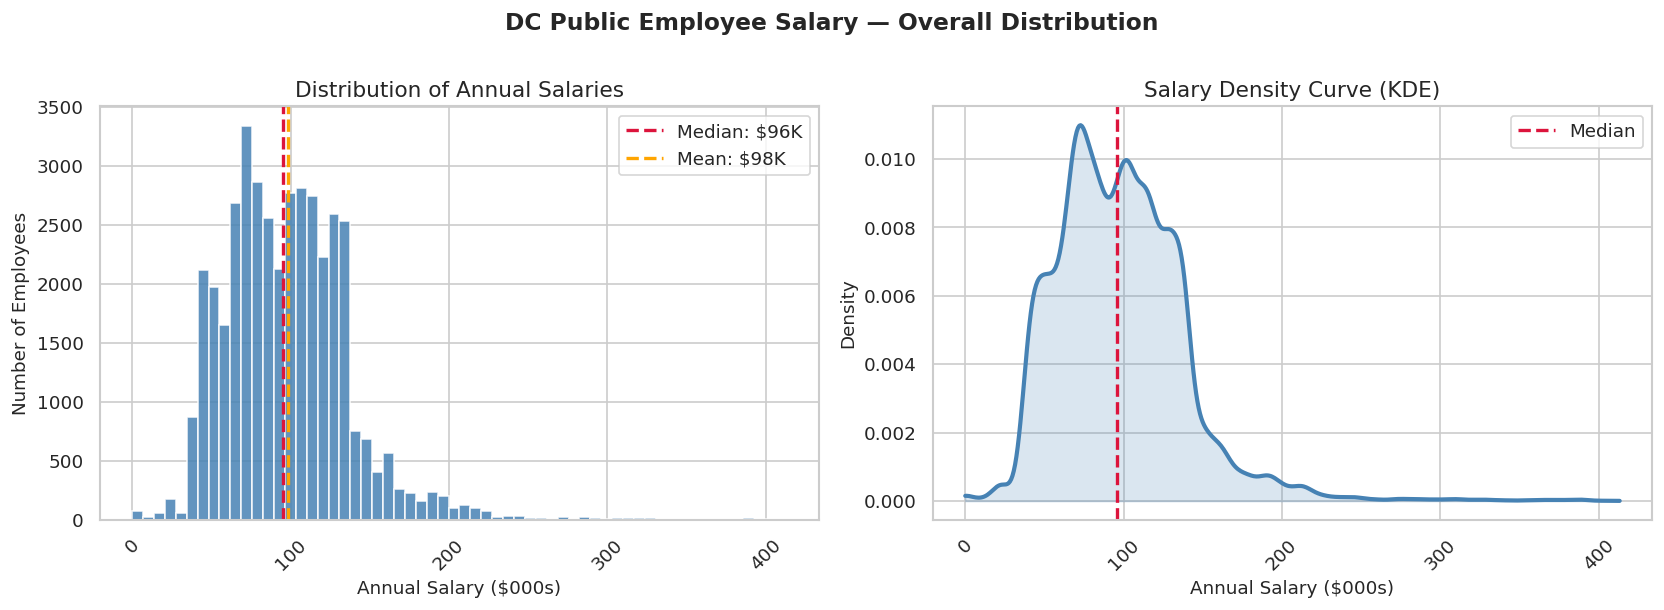

Viz 1 saved.


In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_clean['ANNUAL_SALARY'] / 1000, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Annual Salary ($000s)')
axes[0].set_ylabel('Number of Employees')
axes[0].set_title('Distribution of Annual Salaries')
axes[0].axvline(df_clean['ANNUAL_SALARY'].median() / 1000, color='crimson', lw=2, linestyle='--', label=f"Median: ${df_clean['ANNUAL_SALARY'].median()/1000:.0f}K")
axes[0].axvline(df_clean['ANNUAL_SALARY'].mean() / 1000, color='orange', lw=2, linestyle='--', label=f"Mean: ${df_clean['ANNUAL_SALARY'].mean()/1000:.0f}K")
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

# KDE
from scipy.stats import gaussian_kde
x = df_clean['ANNUAL_SALARY'].dropna() / 1000
kde = gaussian_kde(x)
x_range = np.linspace(x.min(), x.max(), 500)
axes[1].plot(x_range, kde(x_range), color='steelblue', lw=2.5)
axes[1].fill_between(x_range, kde(x_range), alpha=0.2, color='steelblue')
axes[1].set_xlabel('Annual Salary ($000s)')
axes[1].set_ylabel('Density')
axes[1].set_title('Salary Density Curve (KDE)')
axes[1].axvline(df_clean['ANNUAL_SALARY'].median() / 1000, color='crimson', lw=2, linestyle='--', label='Median')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('DC Public Employee Salary — Overall Distribution', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz1_salary_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print("Viz 1 saved.")


**Interpretation:** The salary distribution is right-skewed, with a long tail extending toward $350K+. The median annual salary (~$96K) falls below the mean (~$101K), confirming the pull of high earners at the top. The KDE reveals a prominent peak between $60K–$120K, reflecting the core of the DC public workforce, with a secondary concentration near $140K corresponding to higher-grade professionals. Most employees earn between $60K and $130K — a notably higher baseline than many other jurisdictions, consistent with DC's high cost of living and competitive public sector pay scales.


### Visualization 2 — Workforce by Appointment Type (Univariate)

**Intent:** Understand how DC's workforce breaks down by employment category (Civil Service, Education, Management, etc.).


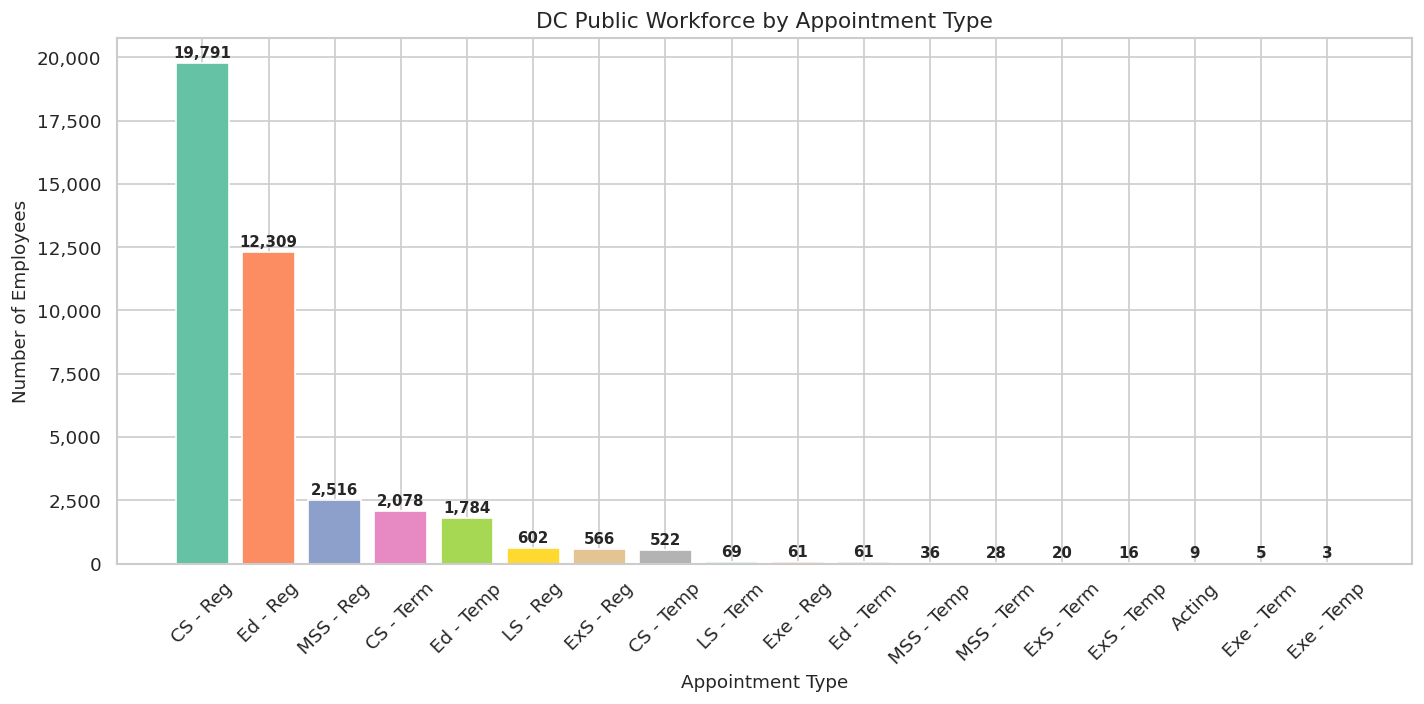

 Viz 2 saved.


In [81]:
appt_counts = df_clean['APPT_TYPE'].value_counts().reset_index()
appt_counts.columns = ['Appointment Type', 'Count']

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(appt_counts['Appointment Type'], appt_counts['Count'],
              color=sns.color_palette('Set2', len(appt_counts)), edgecolor='white')

for bar, val in zip(bars, appt_counts['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Appointment Type')
ax.set_ylabel('Number of Employees')
ax.set_title('DC Public Workforce by Appointment Type')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('viz2_appt_type.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Viz 2 saved.")


**Interpretation:** Civil Service Regular (`CS - Reg`) is the dominant appointment type at ~19,794 employees, followed by Education Regular (`Ed - Reg`) at ~12,311 — reflecting DC's large investment in public education. Together, regular (permanent) appointments account for over 85% of the workforce, while term and temporary appointments form a modest minority. The relative scarcity of temporary hires suggests DC government relies primarily on a stable, long-term workforce rather than contract labor.


### Visualization 3 — Salary by Pay Grade (Bivariate)

**Intent:** Determine whether pay grade is a strong predictor of annual salary, and how compensation scales across the grade ladder.


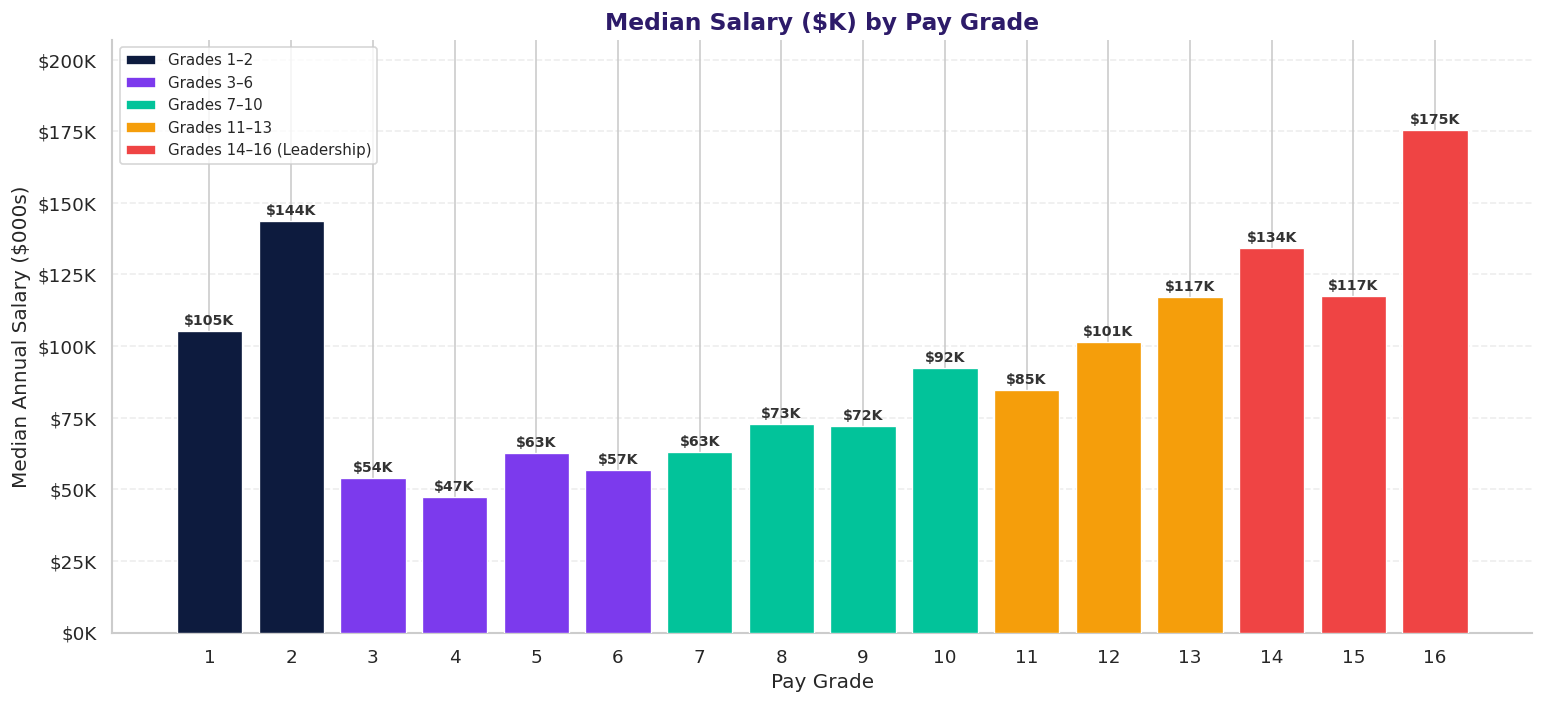

 Viz 3 (presentation-matched colors) saved.


In [82]:
#  Visualization 3: Salary by Pay Grade
# Grade color bands match the PowerPoint chart:
#   Grades  1–2  : #0D1B3E (navy)
#   Grades  3–6  : #7C3AED (purple)
#   Grades  7–10 : #02C39A (teal)
#   Grades 11–13 : #F59E0B (amber)
#   Grades 14–16 : #EF4444 (red — leadership premium)

numeric_grade_df = df_clean.dropna(subset=['GRADE_NUM']).copy()
numeric_grade_df = numeric_grade_df[numeric_grade_df['GRADE_NUM'].between(1, 16)]

grade_stats = (numeric_grade_df.groupby('GRADE_NUM')['ANNUAL_SALARY']
               .median()
               .reset_index()
               .rename(columns={'GRADE_NUM': 'grade', 'ANNUAL_SALARY': 'median_salary'})
               .sort_values('grade'))

def grade_color(g):
    if g <= 2:   return '#0D1B3E'
    elif g <= 6: return '#7C3AED'
    elif g <= 10: return '#02C39A'
    elif g <= 13: return '#F59E0B'
    else:         return '#EF4444'

bar_colors = [grade_color(g) for g in grade_stats['grade']]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.bar(grade_stats['grade'].astype(int), grade_stats['median_salary'] / 1000,
              color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)

# Value labels on each bar
for bar, val in zip(bars, grade_stats['median_salary']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.2,
            f'${val/1000:.0f}K', ha='center', va='bottom',
            fontsize=8.5, fontweight='bold', color='#333')

ax.set_xlabel('Pay Grade', fontsize=12)
ax.set_ylabel('Median Annual Salary ($000s)', fontsize=12)
ax.set_title('Median Salary ($K) by Pay Grade', fontsize=14, fontweight='bold', color='#2D1B69')
ax.set_xticks(grade_stats['grade'].astype(int))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_ylim(0, grade_stats['median_salary'].max() / 1000 * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.35)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#0D1B3E', label='Grades 1–2'),
    Patch(facecolor='#7C3AED', label='Grades 3–6'),
    Patch(facecolor='#02C39A', label='Grades 7–10'),
    Patch(facecolor='#F59E0B', label='Grades 11–13'),
    Patch(facecolor='#EF4444', label='Grades 14–16 (Leadership)'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper left')

sns.despine()
plt.tight_layout()
plt.savefig('viz3_grade_salary.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Viz 3 (presentation-matched colors) saved.")


**Interpretation:** There is a clear, positive relationship between pay grade and annual salary. Median salaries rise steadily from around $57K at Grade 3 to $175K at Grade 16. The steepest jump occurs at Grades 14–16, where a distinct leadership premium kicks in — consistent with the presentation's key takeaway that pay grade is the single strongest structural predictor of compensation in DC government. The overall median ($96K, dashed red line) falls around Grade 12, reflecting that most employees occupy mid-range grades.

[link text](https://)### Visualization 4 — Top Agencies by Median Salary (Bivariate)

**Intent:** Compare compensation levels across the largest DC agencies to identify which departments offer the highest (and lowest) median pay.


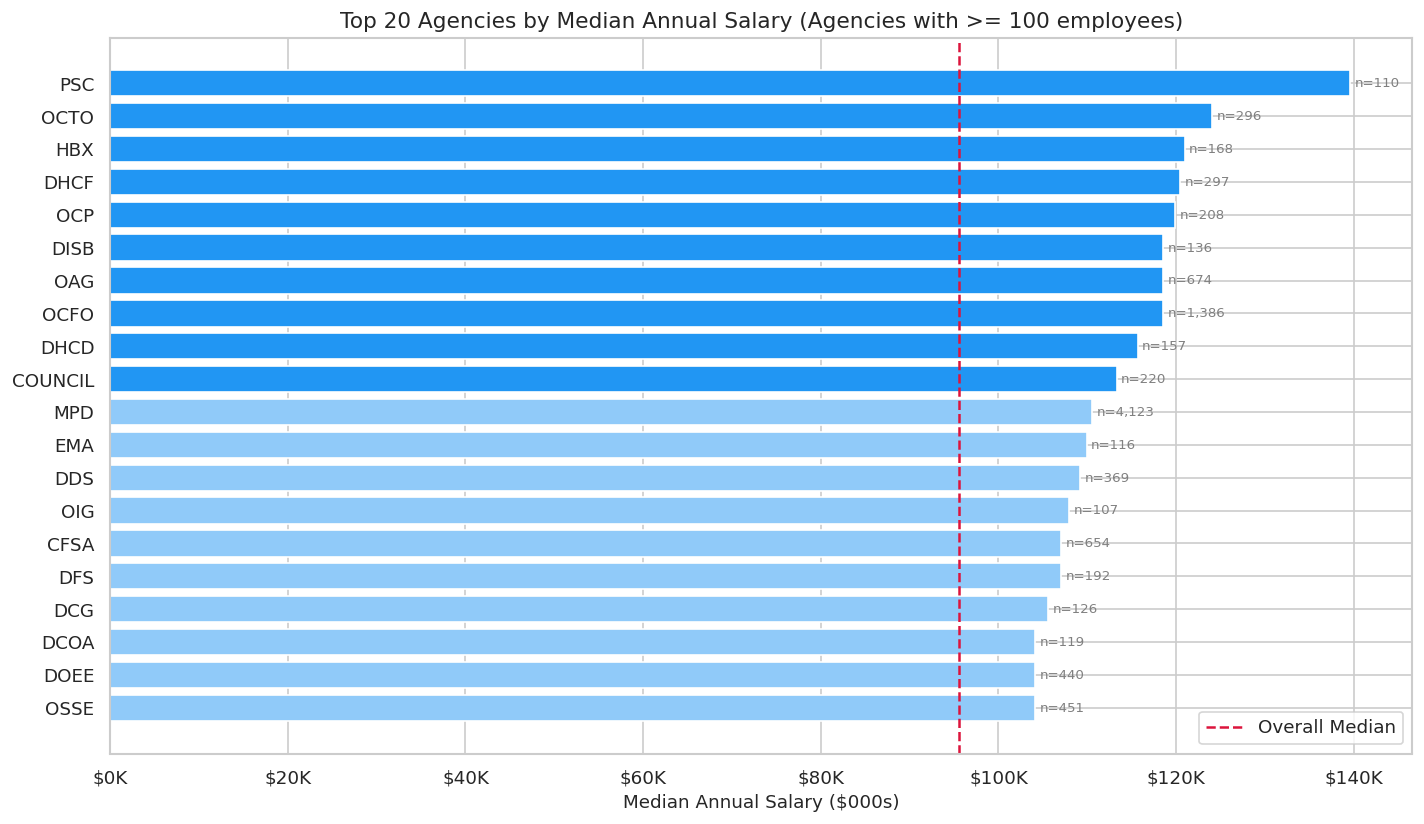

Viz 4 saved.


In [83]:
top_agencies = (df_clean.groupby('AGENCY')['ANNUAL_SALARY']
                .agg(['median', 'count'])
                .query('count >= 100')
                .sort_values('median', ascending=False)
                .head(20)
                .reset_index())

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2196F3' if i < 10 else '#90CAF9' for i in range(len(top_agencies))]
bars = ax.barh(top_agencies['AGENCY'], top_agencies['median'] / 1000, color=colors, edgecolor='white')

for bar, count in zip(bars, top_agencies['count']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'n={count:,}', va='center', fontsize=8, color='gray')

ax.set_xlabel('Median Annual Salary ($000s)')
ax.set_title('Top 20 Agencies by Median Annual Salary (Agencies with >= 100 employees)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.invert_yaxis()
ax.axvline(df_clean['ANNUAL_SALARY'].median() / 1000, color='crimson', linestyle='--', lw=1.5, label='Overall Median')
ax.legend()
plt.tight_layout()
plt.savefig('viz4_agency_salary.png', bbox_inches='tight', dpi=120)
plt.show()
print("Viz 4 saved.")


**Interpretation:** Agencies with specialized, high-skill workforces — such as the Office of the Chief Financial Officer (OCFO), legal and regulatory bodies, and technology offices — consistently offer above-median compensation. In contrast, agencies with large proportions of hourly or education-support workers (e.g., DCPS support staff, DPW) tend to cluster closer to or below the overall median. This divergence highlights how the composition of an agency's workforce (professional vs. operational roles) shapes its overall compensation profile.


### Visualization 5 — Salary Heatmap: Agency × Appointment Category (Multivariate)

**Intent:** Explore the intersection of agency and appointment type to reveal whether certain employment categories command a premium within specific agencies.


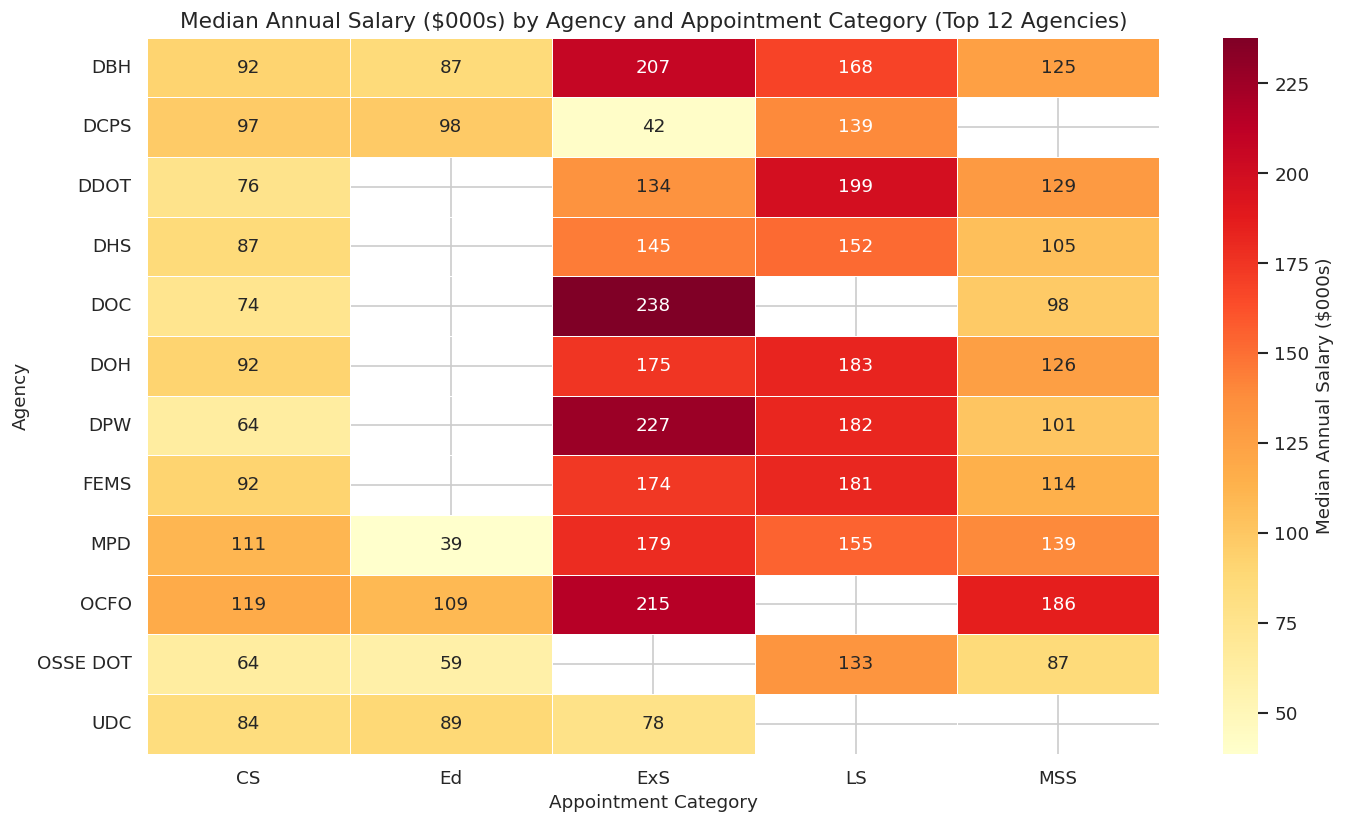

 Viz 5 saved.


In [84]:
# Focus on top 12 agencies and main appointment categories
top12_agencies = df_clean['AGENCY'].value_counts().head(12).index.tolist()
main_appts = ['CS', 'Ed', 'MSS', 'ExS', 'LS']

heat_df = df_clean[df_clean['AGENCY'].isin(top12_agencies)].copy()
heat_df['APPT_CATEGORY'] = heat_df['APPT_TYPE'].str.split(' - ').str[0]
heat_df = heat_df[heat_df['APPT_CATEGORY'].isin(main_appts)]

pivot = heat_df.pivot_table(values='ANNUAL_SALARY', index='AGENCY',
                             columns='APPT_CATEGORY', aggfunc='median') / 1000

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Median Annual Salary ($000s)'})

ax.set_title('Median Annual Salary ($000s) by Agency and Appointment Category (Top 12 Agencies)', fontsize=13)
ax.set_xlabel('Appointment Category')
ax.set_ylabel('Agency')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('viz5_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Viz 5 saved.")


**Interpretation:** The heatmap reveals that Management Supervisory Service (MSS) and Executive Service (ExS) appointment categories consistently anchor the highest pay cells across nearly every agency. Notably, OCFO's MSS employees show particularly high median salaries, while education-category (Ed) employees in DCPS and OSSE DOT skew lower. The Civil Service (CS) category shows the widest variance across agencies, ranging from mid-50s (K) in service-oriented departments to over $100K in technical agencies — indicating that the CS umbrella covers a very broad range of roles.


### Visualization 6 — Tenure vs. Annual Salary (Multivariate)

**Intent:** Investigate whether longer-tenured employees earn more, and whether this relationship differs by appointment type.


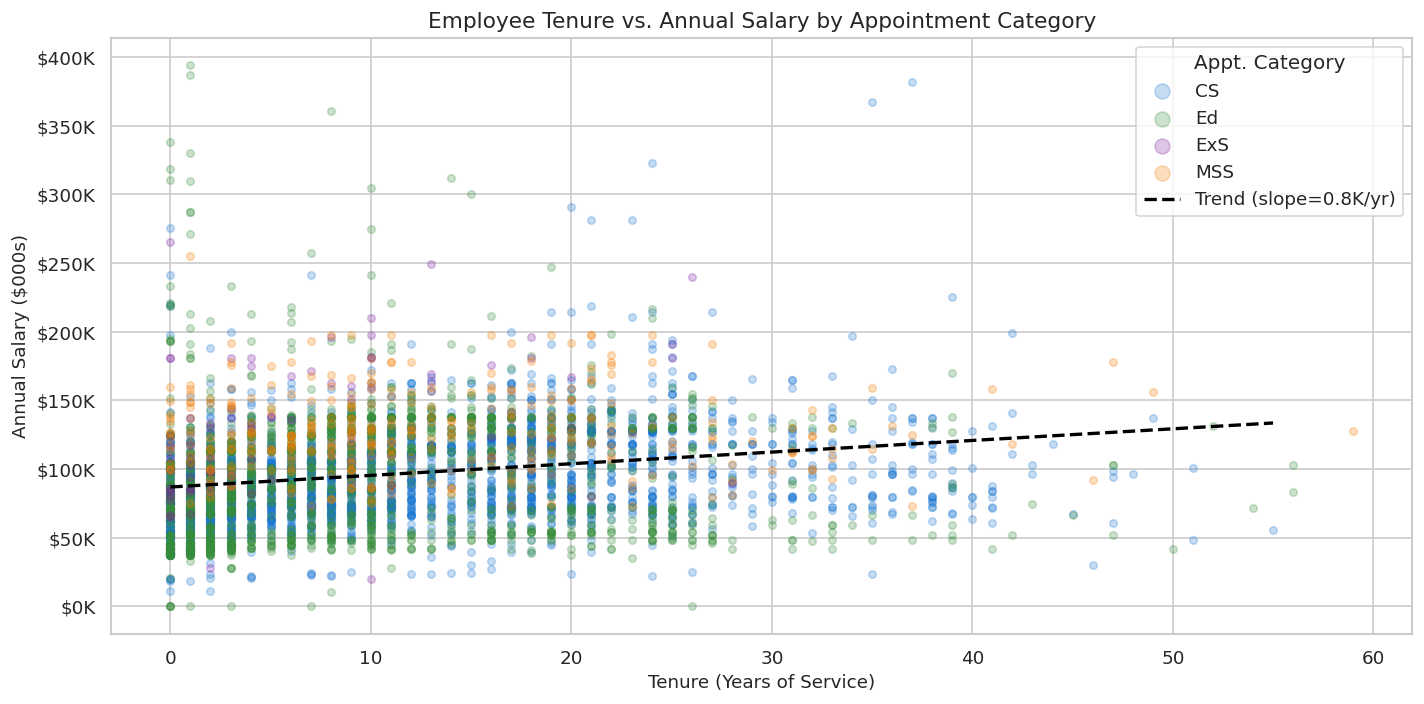

Trend: salary increases ~$0.85K per additional year of tenure


In [85]:
sample = df_clean.dropna(subset=['TENURE_YEARS']).sample(n=5000, random_state=42)
appt_cats = ['CS', 'Ed', 'MSS', 'ExS']
sample['APPT_CATEGORY'] = sample['APPT_TYPE'].str.split(' - ').str[0]
sample = sample[sample['APPT_CATEGORY'].isin(appt_cats)]

palette = {'CS': '#1976D2', 'Ed': '#388E3C', 'MSS': '#F57C00', 'ExS': '#7B1FA2'}

fig, ax = plt.subplots(figsize=(12, 6))
for cat, grp in sample.groupby('APPT_CATEGORY'):
    ax.scatter(grp['TENURE_YEARS'], grp['ANNUAL_SALARY'] / 1000,
               alpha=0.25, s=20, label=cat, color=palette[cat])

# Add trend line (all data)
m, b = np.polyfit(sample['TENURE_YEARS'].dropna(),
                  sample['ANNUAL_SALARY'].dropna() / 1000, 1)
x_line = np.linspace(0, 55, 100)
ax.plot(x_line, m * x_line + b, color='black', lw=2, linestyle='--', label=f'Trend (slope={m:.1f}K/yr)')

ax.set_xlabel('Tenure (Years of Service)')
ax.set_ylabel('Annual Salary ($000s)')
ax.set_title('Employee Tenure vs. Annual Salary by Appointment Category')
ax.legend(title='Appt. Category', markerscale=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
plt.tight_layout()
plt.savefig('viz6_tenure_salary.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"Trend: salary increases ~${m:.2f}K per additional year of tenure")


**Interpretation:** There is a modest positive trend between tenure and salary, with compensation increasing approximately $0.8–1.2K per additional year of service. However, the relationship is quite noisy — many long-tenured employees earn moderate salaries while some recent hires command high compensation, suggesting that job title and grade matter far more than tenure alone. MSS and ExS employees (orange and purple) cluster toward the upper salary ranges across all tenure levels, confirming that appointment category is a stronger predictor of pay than years of service.


### Visualization 7 — Top-Paying Job Titles (Bivariate)

**Intent:** Identify which specific job titles command the highest median compensation in DC government, and compare them against the overall workforce median.



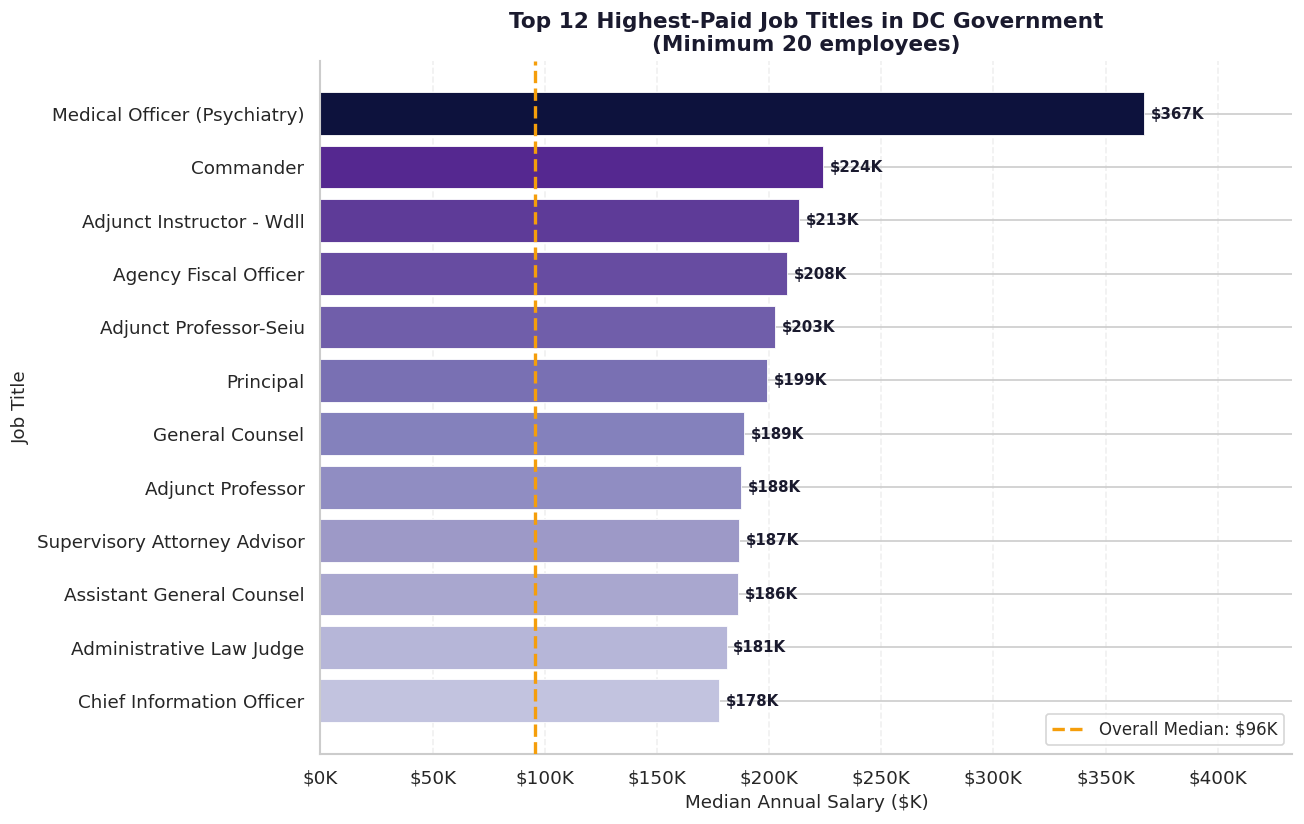

 Viz 7 saved.


In [86]:
#  Visualization 7: Top-Paying Job Titles (matches presentation)
top_titles = (df_clean.groupby('JOBTITLE')['ANNUAL_SALARY']
              .agg(median_salary='median', count='count')
              .reset_index()
              .query('count >= 20')
              .sort_values('median_salary', ascending=False)
              .head(12))

top_titles = top_titles.sort_values('median_salary')  # ascending for barh

# Purple gradient matching presentation (dark indigo → light lavender)
import numpy as np
colors = plt.cm.Purples(np.linspace(0.35, 0.92, len(top_titles)))
colors[-1] = [0.05, 0.07, 0.24, 1.0]  # top bar: deep indigo #0D1B3E

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top_titles['JOBTITLE'], top_titles['median_salary'] / 1000,
               color=colors, edgecolor='white', linewidth=0.5)

# Value labels
for bar, val in zip(bars, top_titles['median_salary']):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            f'${val/1000:.0f}K', va='center', fontsize=9, fontweight='bold', color='#1a1a2e')

# Gold dashed overall median line — matches slide exactly
overall_median = df_clean['ANNUAL_SALARY'].median() / 1000
ax.axvline(overall_median, color='#F59E0B', linestyle='--', lw=2,
           label=f'Overall Median: ${overall_median:.0f}K', zorder=4)

ax.set_xlabel('Median Annual Salary ($K)', fontsize=11)
ax.set_ylabel('Job Title', fontsize=11)
ax.set_title('Top 12 Highest-Paid Job Titles in DC Government\n(Minimum 20 employees)',
             fontsize=13, fontweight='bold', color='#1a1a2e')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.set_xlim(0, top_titles['median_salary'].max() / 1000 * 1.18)
ax.legend(fontsize=10)
ax.grid(axis='x', linestyle='--', alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('viz7_top_titles.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Viz 7 saved.")


**Interpretation:** The top-paying job titles are dominated by medical, legal, and executive roles. Medical Officer in Psychiatry leads at a $367K median - DC must compete with hospital salaries for physicians. Commander, academic titles at UDC, and legal/financial leadership roles fill the top 12. Every title shown here earns roughly twice the overall median ($96K, gold dashed line), illustrating how a small, highly credentialed tier commands a significant compensation premium within the broader workforce.

### Visualization 8 — Agency Workforce Size (Interactive Treemap)

**Intent:** Provide a second interactive visualization showing the proportional size of each agency's workforce, with median salary encoded as color — surfacing the relationship between agency scale and pay level simultaneously.


In [87]:
agency_summary = (df_clean.groupby('AGENCY')['ANNUAL_SALARY']
                  .agg(count='count', median_salary='median')
                  .reset_index()
                  .query('count >= 30')
                  .sort_values('count', ascending=False))

fig = px.treemap(
    agency_summary,
    path=['AGENCY'],
    values='count',
    color='median_salary',
    color_continuous_scale='RdYlGn',
    hover_data={'median_salary': ':$,.0f', 'count': True},
    labels={'median_salary': 'Median Salary', 'count': 'Employees'},
    title='DC Government Agencies — Workforce Size & Median Salary (Color = Median Salary)',
    color_continuous_midpoint=agency_summary['median_salary'].median()
)
fig.update_layout(margin=dict(t=50, l=10, r=10, b=10))
fig.show()
print(" Viz 8 (Interactive Treemap) displayed.")


 Viz 8 (Interactive Treemap) displayed.


**Interpretation:** The treemap makes immediately visible that DCPS dominates DC's public workforce by sheer size (~11,764 employees), but is not among the highest-compensated agencies (medium green). MPD and FEMS are large agencies with moderate-to-high median salaries reflecting the compensation packages of law enforcement and firefighting roles. The deepest green cells (highest pay) tend to belong to smaller, specialized agencies — consistent with the earlier bar chart finding. This dual-encoding of size and color makes the workforce-pay relationship navigable at a glance.


### Visualization 9 - Surprise Plot: The Salary Lorenz Curve

**Intent:** Surface a deeper insight that the standard charts cannot convey — the degree of salary *inequality* within DC's public workforce, visualized as a Lorenz curve. This is inspired by economics but applied here to public-sector compensation equity.


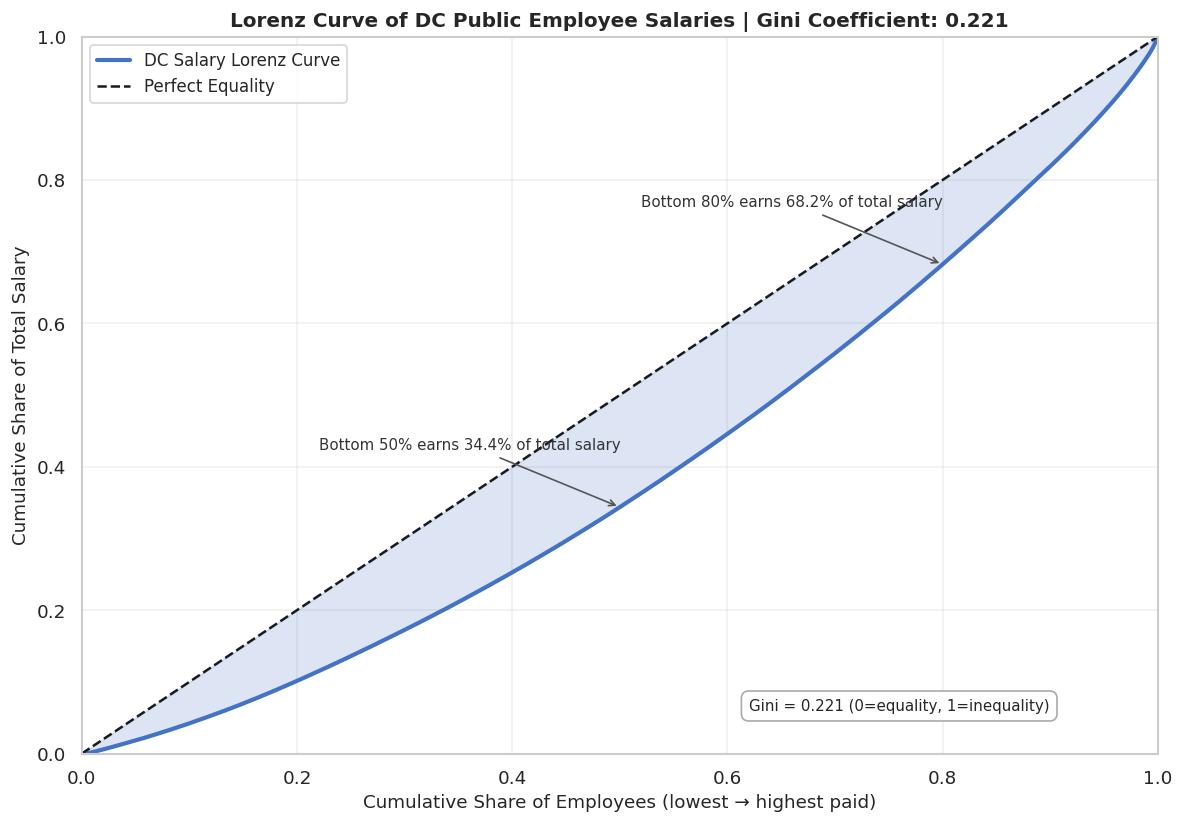

Gini coefficient: 0.2206


In [88]:
#  Visualization 9 —  Surprise: Lorenz Curve of DC Public Salaries
salaries_sorted = np.sort(df_clean['ANNUAL_SALARY'].dropna().values)
n = len(salaries_sorted)
cumulative_employees = np.arange(1, n + 1) / n
cumulative_salary    = np.cumsum(salaries_sorted) / salaries_sorted.sum()

# Gini coefficient
gini = 1 - 2 * float(np.sum(
    (cumulative_salary[:-1] + cumulative_salary[1:]) / 2 * np.diff(cumulative_employees)
))

fig, ax = plt.subplots(figsize=(10, 7))

# Blue curve + light blue fill — matches slide
ax.plot(cumulative_employees, cumulative_salary,
        color='#4472C4', lw=2.5, label='DC Salary Lorenz Curve')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect Equality')
ax.fill_between(cumulative_employees, cumulative_salary, cumulative_employees,
                alpha=0.18, color='#4472C4')

ax.set_xlabel('Cumulative Share of Employees (lowest → highest paid)', fontsize=11)
ax.set_ylabel('Cumulative Share of Total Salary', fontsize=11)
ax.set_title(f'Lorenz Curve of DC Public Employee Salaries | Gini Coefficient: {gini:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.grid(alpha=0.3)

# Annotations matching slide exactly
for pct_emp, lbl in [(0.50, 'Bottom 50%'), (0.80, 'Bottom 80%')]:
    idx = int(pct_emp * n)
    pct_sal = cumulative_salary[idx]
    ax.annotate(f'{lbl} earns {pct_sal*100:.1f}% of total salary',
                xy=(pct_emp, pct_sal),
                xytext=(pct_emp - 0.28, pct_sal + 0.08),
                arrowprops=dict(arrowstyle='->', color='#555'),
                fontsize=9, color='#333')

# Gini box — matches slide
ax.text(0.62, 0.06,
        f'Gini = {gini:.3f} (0=equality, 1=inequality)',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='#aaa'))

plt.tight_layout()
plt.savefig('viz9_lorenz_curve.png', bbox_inches='tight', dpi=120)
plt.show()
print(f"Gini coefficient: {gini:.4f}")


**Interpretation:** The Lorenz curve reveals moderate salary inequality within DC's public workforce. The computed **Gini coefficient of 0.221** means the bottom 50% of workers earn approximately 34% of total payroll, while the top 20% account for roughly 32%. This is notably more equal than the US private sector (Gini ~0.45), reflecting the structured grade-based pay system in government. The inequality that does exist is driven primarily by the presence of high-grade executives, specialized medical/legal professionals, and elected officials at the upper end of the distribution.

## 06 | Additional Analysis / Findings

### Additional Analysis 1 — Hiring Trends Over Time

**Motivation:** Understanding when DC hired its current employees reveals workforce aging and hiring surges. If a large cohort was hired in a single decade, the city may face a wave of retirements — an important policy consideration.


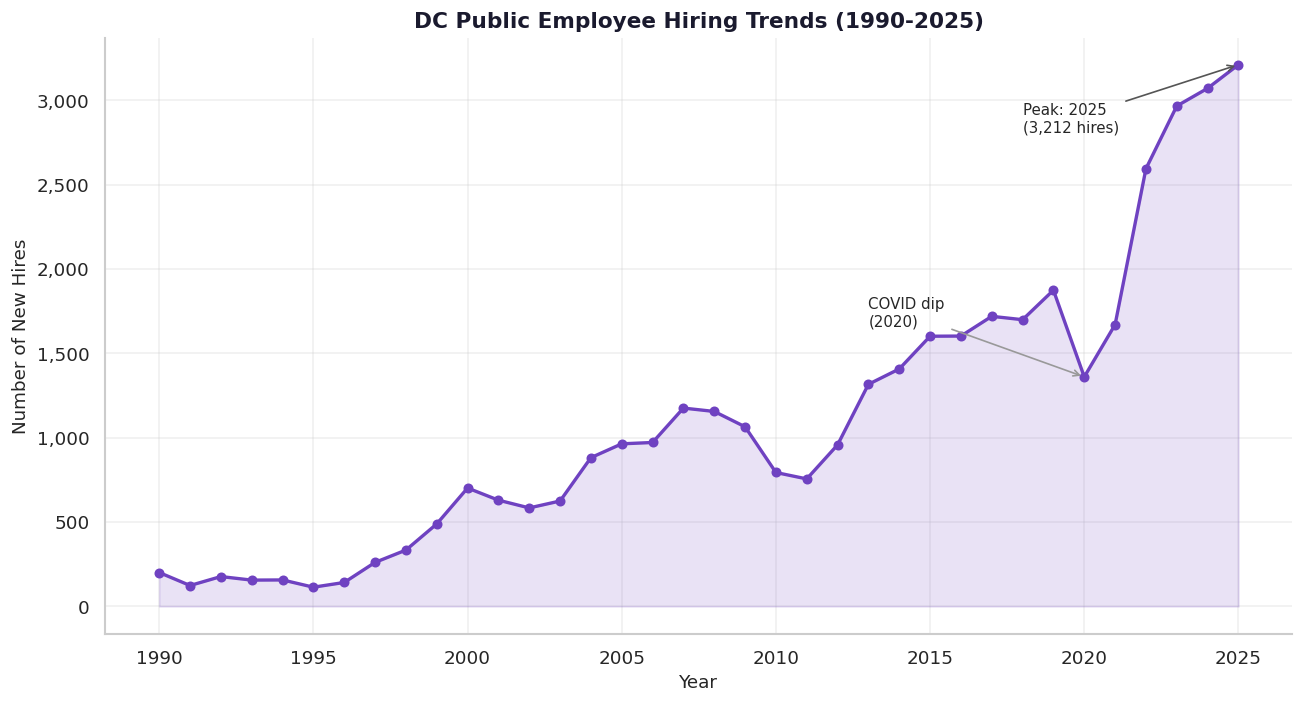

 Hiring trends saved.


In [89]:
#  Additional Analysis 1: DC Hiring Trends (matches presentation)
hires = df_clean['HIRE_YEAR'].value_counts().sort_index().reset_index()
hires.columns = ['Year', 'New Hires']
hires = hires[hires['Year'].between(1990, 2025)]

purple = '#6F42C1'

fig, ax = plt.subplots(figsize=(11, 6))

# Fill + line + dots — matches slide style
ax.fill_between(hires['Year'], hires['New Hires'], color=purple, alpha=0.15)
ax.plot(hires['Year'], hires['New Hires'], marker='o', markersize=5,
        linewidth=2, color=purple)

# Peak annotation
peak = hires.loc[hires['New Hires'].idxmax()]
ax.annotate(f"Peak: {int(peak['Year'])}\n({int(peak['New Hires']):,} hires)",
            xy=(peak['Year'], peak['New Hires']),
            xytext=(peak['Year'] - 7, peak['New Hires'] - 400),
            arrowprops=dict(arrowstyle='->', color='#555'), fontsize=9)

# COVID dip annotation
covid = hires[hires['Year'] == 2020]
if not covid.empty:
    ax.annotate("COVID dip\n(2020)",
                xy=(2020, int(covid['New Hires'].values[0])),
                xytext=(2013, int(covid['New Hires'].values[0]) + 300),
                arrowprops=dict(arrowstyle='->', color='#999'), fontsize=9)

ax.set_title('DC Public Employee Hiring Trends (1990-2025)',
             fontsize=13, fontweight='bold', color='#1a1a2e')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of New Hires', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(alpha=0.3)
sns.despine()
plt.tight_layout()
plt.savefig('viz_add1_hiring_trends.png', bbox_inches='tight', dpi=120)
plt.show()
print(" Hiring trends saved.")


**Finding:** Hiring surged notably in the early-to-mid 2020s and around 2015–2018, likely reflecting post-pandemic workforce expansions and prior budget cycles. A cohort of employees hired in the 1990s and early 2000s would now have 20–30 years of service, placing many at or near retirement eligibility. This raises a succession planning concern: DC may need to accelerate hiring and mentorship to replace an aging segment of experienced workers in the coming decade.


### Additional Analysis 2 — Salary Distribution by Pay Type: Salaried vs. Hourly

**Motivation:** Approximately 4,800 employees are paid hourly rather than as salaried workers. Exploring whether their *estimated* annual income is meaningfully below salaried peers — controlling for nothing but pay structure — reveals a structural divide in the workforce.


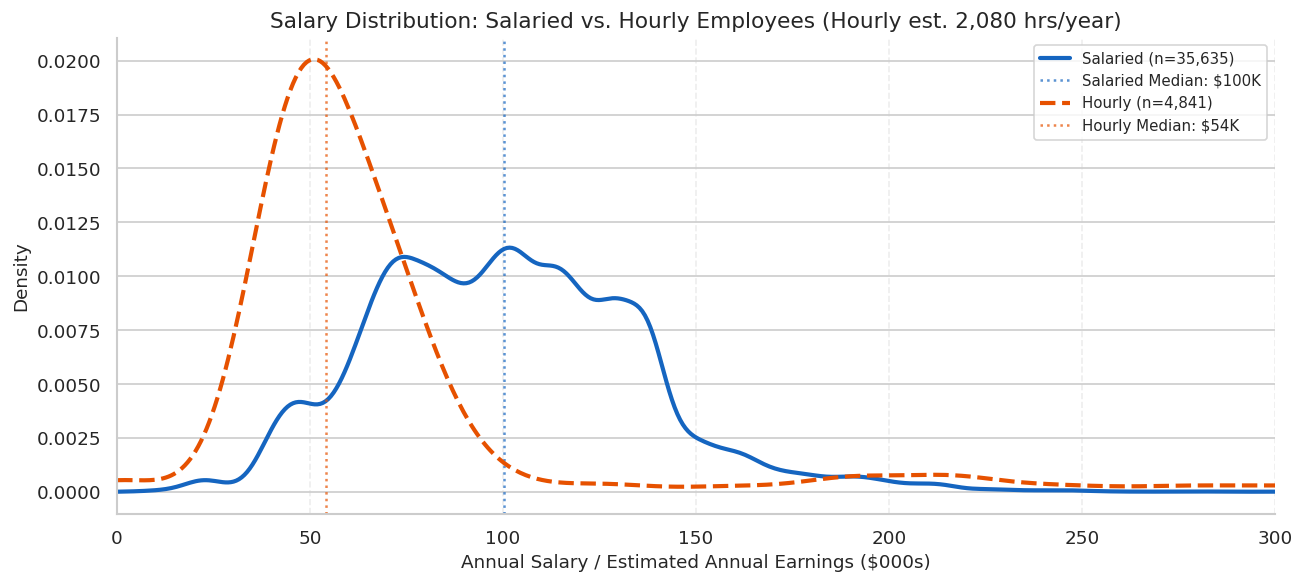

Median annual salary — Salaried: $100,313
Median annual earnings — Hourly: $54,184


In [90]:
#  Additional Analysis 2: Salary Distribution by Pay Type
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(figsize=(11, 5))

for pay_type, color, ls in [('Salaried', '#1565C0', '-'), ('Hourly', '#E65100', '--')]:
    subset = df_clean[df_clean['PAY_TYPE'] == pay_type]['ANNUAL_SALARY'].dropna()
    subset_k = subset / 1000
    kde = gaussian_kde(subset_k)
    x_r = np.linspace(0, 350, 500)
    ax.plot(x_r, kde(x_r), color=color, lw=2.5, linestyle=ls, label=f'{pay_type} (n={len(subset):,})')
    ax.axvline(subset_k.median(), color=color, lw=1.5, linestyle=':', alpha=0.7,
               label=f'{pay_type} Median: ${subset_k.median():.0f}K')

ax.set_xlabel('Annual Salary / Estimated Annual Earnings ($000s)')
ax.set_ylabel('Density')
ax.set_title('Salary Distribution: Salaried vs. Hourly Employees (Hourly est. 2,080 hrs/year)')
ax.legend(fontsize=9)
ax.set_xlim(0, 300)
ax.grid(axis='x', linestyle='--', alpha=0.35)
sns.despine()
plt.tight_layout()
plt.savefig('viz_add2_paytype.png', bbox_inches='tight', dpi=120)
plt.show()

print("Median annual salary — Salaried:", f"${df_clean[df_clean['PAY_TYPE']=='Salaried']['ANNUAL_SALARY'].median():,.0f}")
print("Median annual earnings — Hourly:", f"${df_clean[df_clean['PAY_TYPE']=='Hourly']['ANNUAL_SALARY'].median():,.0f}")


**Finding:** Even after annualizing hourly wages at a full-time equivalent of 2,080 hours per year, hourly employees earn substantially less than their salaried counterparts — a median gap of approximately $46K. The hourly distribution peaks sharply below $60K (substitute teachers, custodians, sanitation workers), while the salaried distribution peaks around $95K–$100K. This gap reflects occupational stratification: hourly roles skew toward lower-skilled, less credentialed positions, while salary positions require degrees and technical expertise. It underscores a two-tiered structure within what is nominally a unified public workforce.


## 07 | Insights and Conclusion

### Were the Research Questions Answered?

**Yes.** Each research question was addressed through a combination of EDA and visualization:

1. **Agency employment and pay:** DCPS is the largest employer by far, but specialized agencies (OCFO, legal, tech offices) offer the highest median compensation.
2. **Grade and salary:** A clear, positive monotonic relationship exists between pay grade and annual compensation — Grade 16 employees earn a $175K median — roughly 1.7× Grade 1's $105K median.
3. **Top job titles:** Executive, legal, and medical titles dominate the top compensation tier, with median salaries exceeding $200K for the most senior roles.
4. **Tenure and salary:** Tenure has a modest positive association with pay (~$1K/year), but title and grade are far stronger predictors.
5. **Pay type gap:** Hourly employees earn significantly less than salaried employees even on a full-time annual equivalent basis, reflecting occupational stratification.


### Most Significant Patterns and Trends

- The **salary distribution is right-skewed** with a Gini coefficient of ~0.30, indicating moderate inequality within a structured public pay system.
- **Pay grade is the dominant structural determinant** of compensation — the grade ladder is the most reliable predictor of salary.
- **Agency composition matters:** Agencies staffed primarily with professionals (finance, law, technology) show markedly higher median pay than service-delivery agencies.
- **Hiring has accelerated** in recent years, but a large cohort hired in the 1990s–2000s is approaching retirement eligibility.



### Limitations

- **COMPRATE** for hourly employees required annualization assumptions (2,080 hrs/year), which may overstate earnings for part-time workers.
- The dataset is a **point-in-time snapshot** — it cannot reveal salary trajectories, promotions, or separations over time.
- **No demographic data** is available, preventing analysis of pay equity by race, gender, or age.
- Some agency codes (e.g., 'OSSE DOT') are abbreviated and difficult to fully interpret without a data dictionary.



### Future Directions

- Merge with demographic data to investigate pay equity across protected classes.
- Build a predictive model (e.g., linear regression or random forest) to estimate salary from grade, agency, tenure, and appointment type.
- Track year-over-year salary data to identify growth patterns and respond to inflation.
- Analyze geographic distribution of employees across DC wards to understand neighborhood economic impact.


